# Examen Aplicado — Machine Learning I

**Predicción del valor medio de vivienda en California (California Housing Dataset)**

**Autor:** Alexander Valderrama

**Asignatura:** Machine Learning I — Examen individual

---

**Ficha del dataset**

- **Nombre del dataset:** California Housing Dataset
- **Fuente:** Scikit-learn `sklearn.datasets.fetch_california_housing` (originalmente de StatLib, Universidad Carnegie Mellon)
- **URL pública verificable:** https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset (fuente original: https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html)
- **Número de filas:** 20.640
- **Número de columnas:** 9 (8 variables predictoras + 1 variable objetivo)
- **Variable objetivo:** `MedHouseVal` (valor medio de vivienda por grupo de manzanas censales, en cientos de miles de dólares, con tope artificial en 5,00001 ≈ USD 500.000)
- **Tipo de tarea:** **Regresión**

In [ ]:
# Librerias


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

plt.style.use("ggplot")
SEED = 42
np.random.seed(SEED)

import os
import time
import warnings
warnings.filterwarnings("ignore")

# Carpeta para guardar todas las figuras (requisito del repositorio GitHub)
os.makedirs("figures", exist_ok=True)

In [ ]:
# Cargar el dataset (viene incluido en scikit-learn, no requiere descarga externa)
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.shape

Dimensiones: 20,640 filas x 9 columnas


(20640, 9)

In [ ]:
# Tipos de dato, informacion general y estadisticos descriptivos
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Análisis de valores faltantes

MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64


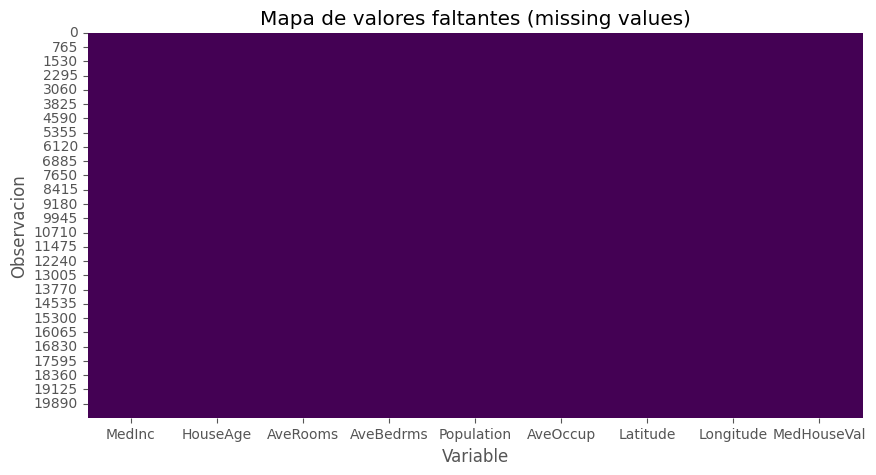

In [ ]:
# Porcentaje de nulos por columna
pct_nulos = (df.isnull().mean() * 100).round(2)
print(pct_nulos)

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores faltantes (missing values)")
plt.xlabel("Variable")
plt.ylabel("Observacion")
plt.savefig("figures/missing_values_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Justificación:** el dataset no presenta valores faltantes en ninguna de sus 9 columnas (0,00% en todas). Por lo tanto, no se requiere imputación (mediana/moda/KNN) ni eliminación de columnas. El paso de `SimpleImputer` se incluye de todas formas en el `ColumnTransformer` (Sección de Preprocesamiento) por buena práctica y reproducibilidad ante datos futuros, aunque en este dataset no tenga efecto.

## Detección y tratamiento de outliers (método IQR)

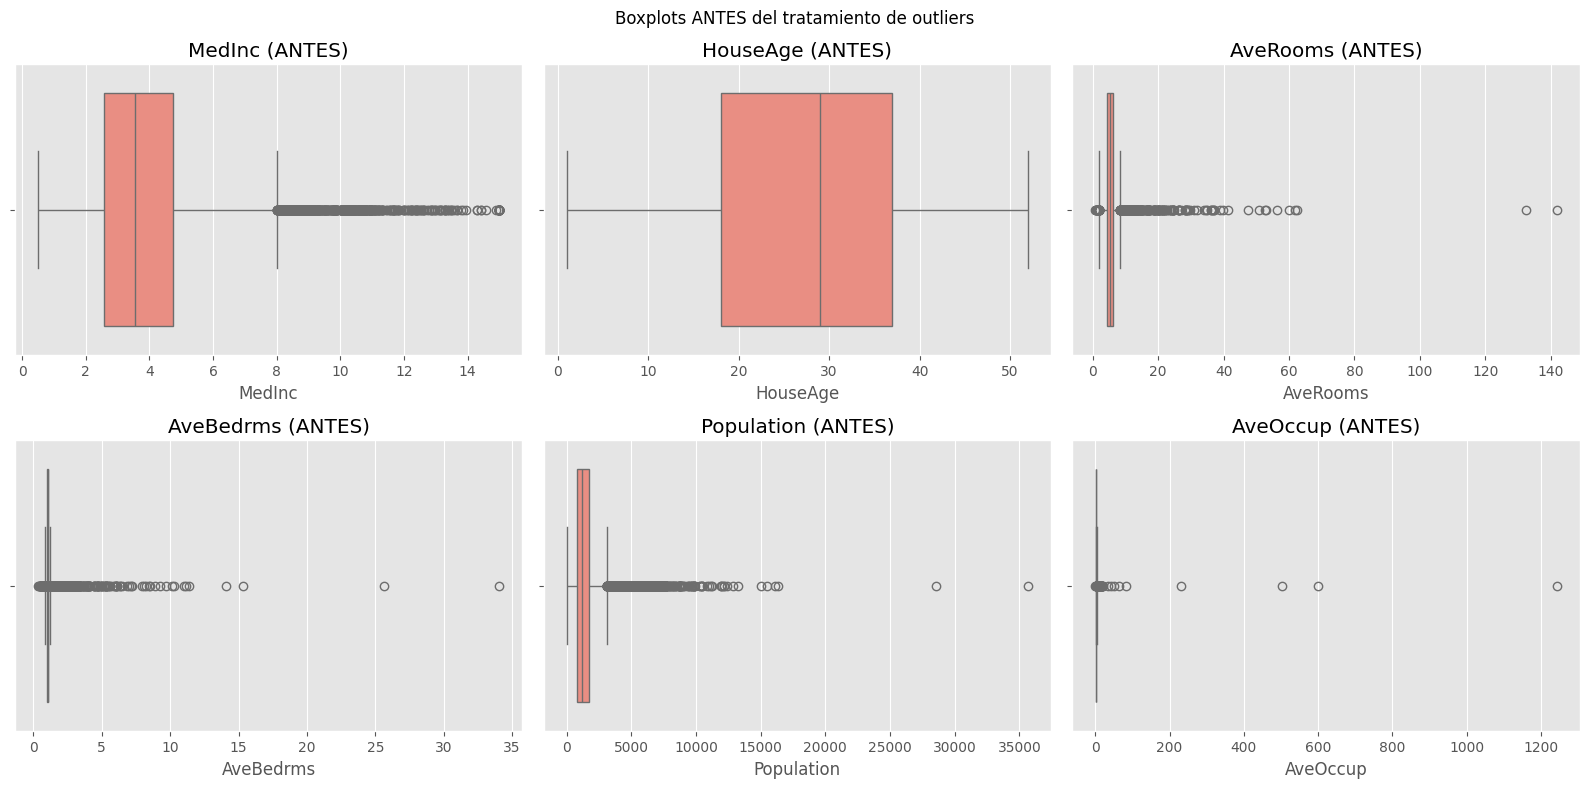

,Variable,% outliers,Limite inferior,Limite superior,Max observado
0,MedInc,3.30,-0.71,8.01,15.00
1,HouseAge,0.00,-10.50,65.50,52.00
2,AveRooms,2.48,2.02,8.47,141.91
3,AveBedrms,6.90,0.87,1.24,34.07
4,Population,5.79,-620.00,3132.00,35682.00
5,AveOccup,3.44,1.15,4.56,1243.33


In [ ]:
# Deteccion de outliers con el metodo IQR en las variables numericas clave
num_cols_outliers = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
resumen_outliers = []
for ax, col in zip(axes.ravel(), num_cols_outliers):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < lo) | (df[col] > hi)).sum())
    resumen_outliers.append({"Variable": col, "% outliers": round(n_out / len(df) * 100, 2),
                              "Limite inferior": round(lo, 2), "Limite superior": round(hi, 2),
                              "Max observado": round(df[col].max(), 2)})
    sns.boxplot(x=df[col], ax=ax, color="salmon")
    ax.set_title(f"{col} (ANTES)")
fig.suptitle("Boxplots ANTES del tratamiento de outliers")
plt.tight_layout()
plt.savefig("figures/boxplots_antes.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(resumen_outliers)

**Justificación de la decisión tomada:** se opta por **capar (winsorizar)** los valores fuera del rango IQR (en vez de eliminar filas o imputar) para las 6 variables numéricas clave. La razón es que estos valores extremos —por ejemplo, `AveOccup` llega a 1.243 personas por hogar cuando el 75% de los datos está bajo 4,56— corresponden a grupos de manzanas censales reales, no a errores de captura, por lo que eliminarlos perdería información real; pero al mismo tiempo, su magnitud extrema distorsiona fuertemente los métodos basados en distancia (PCA y K-Means) que se aplican más adelante. Capar el valor al límite superior/inferior del IQR conserva las 20.640 observaciones y reduce la influencia desproporcionada de estos pocos casos extremos.

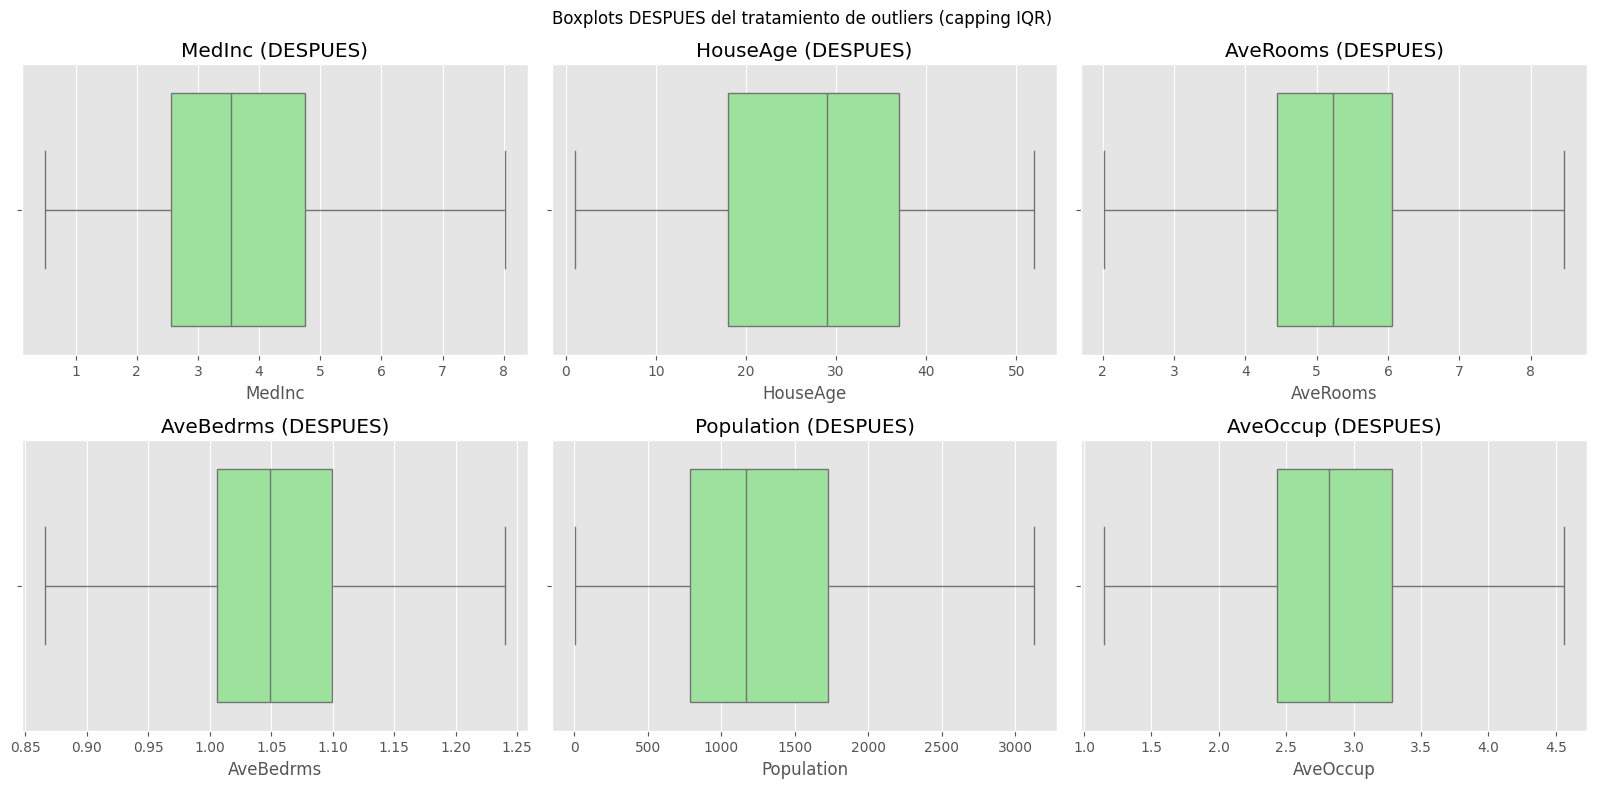

In [ ]:
# Tratamiento: capping (winsorizacion) al rango IQR
df_tratado = df.copy()
limites = {}
for col in num_cols_outliers:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = max(q1 - 1.5 * iqr, df[col].min()), q3 + 1.5 * iqr
    limites[col] = (lo, hi)
    df_tratado[col] = df_tratado[col].clip(lo, hi)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_cols_outliers):
    sns.boxplot(x=df_tratado[col], ax=ax, color="lightgreen")
    ax.set_title(f"{col} (DESPUES)")
fig.suptitle("Boxplots DESPUES del tratamiento de outliers (capping IQR)")
plt.tight_layout()
plt.savefig("figures/boxplots_despues.png", dpi=150, bbox_inches="tight")
plt.show()

## Distribución de la variable objetivo

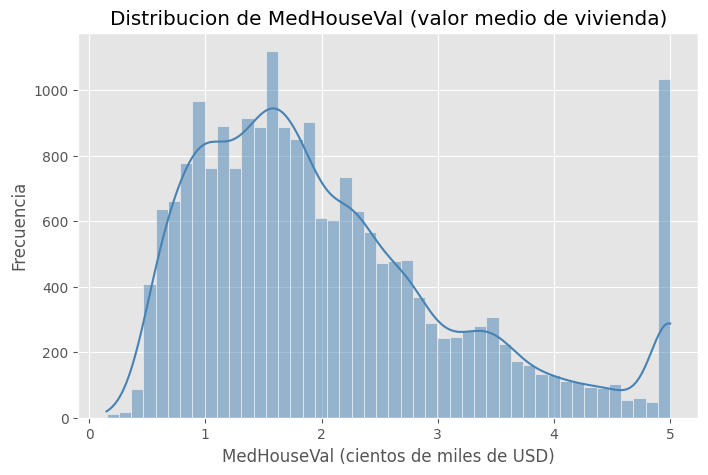

Skewness de MedHouseVal: 0.9777
Observaciones en el tope artificial (>=4.999): 992


In [ ]:
# Histograma + KDE de la variable objetivo y calculo de asimetria (skewness)
plt.figure(figsize=(8, 5))
sns.histplot(df_tratado["MedHouseVal"], kde=True, color="steelblue")
plt.title("Distribucion de MedHouseVal (valor medio de vivienda)")
plt.xlabel("MedHouseVal (cientos de miles de USD)")
plt.ylabel("Frecuencia")
plt.savefig("figures/distribucion_target.png", dpi=150, bbox_inches="tight")
plt.show()

skew_target = skew(df_tratado["MedHouseVal"])
print(f"Skewness de MedHouseVal: {skew_target:.4f}")
print(f"Observaciones en el tope artificial (>=4.999): {(df_tratado['MedHouseVal'] >= 4.999).sum()}")

**Evaluación de transformación logarítmica:** la asimetría de `MedHouseVal` es 0,9777, **por debajo** del umbral de 1,0 establecido, por lo que **no se aplica** transformación logarítmica. Se observa, sin embargo, que 992 observaciones (4,8% del total) están concentradas exactamente en el valor tope de 5,00001 — un artefacto conocido de este dataset: el valor original fue truncado/censurado en USD 500.000 al momento de su construcción. Esta censura, más que la asimetría en sí, es la que genera la cola derecha observada, y una transformación logarítmica no la corrige (el tope seguiría generando una acumulación de puntos). Este hallazgo se retoma en la sección de análisis de errores del modelo.

## Visualizaciones exploratorias adicionales

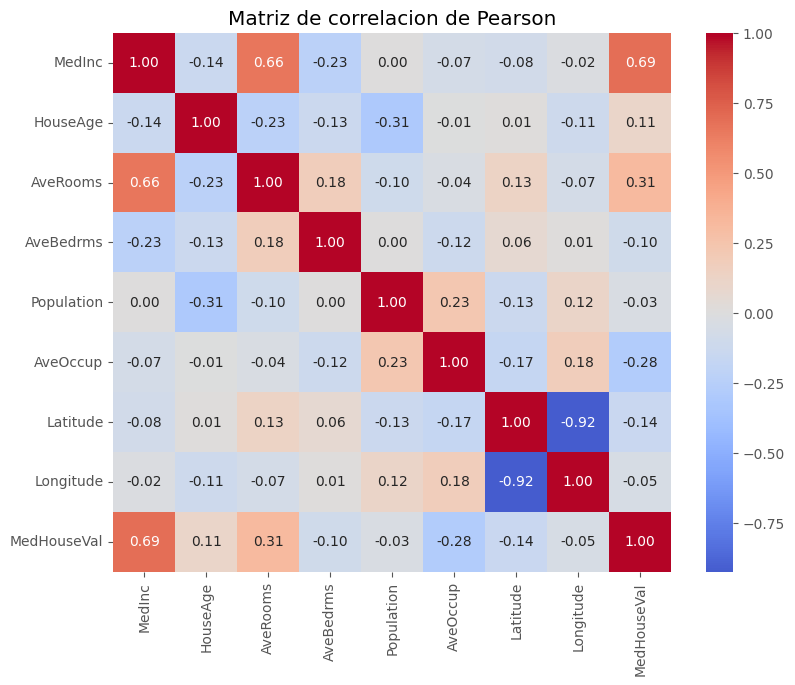

In [ ]:
# 1. Heatmap de correlacion de Pearson
plt.figure(figsize=(9, 7))
corr = df_tratado.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlacion de Pearson")
plt.savefig("figures/correlacion_pearson.png", dpi=150, bbox_inches="tight")
plt.show()

Top 2 variables mas correlacionadas con MedHouseVal: ['MedInc', 'AveRooms']


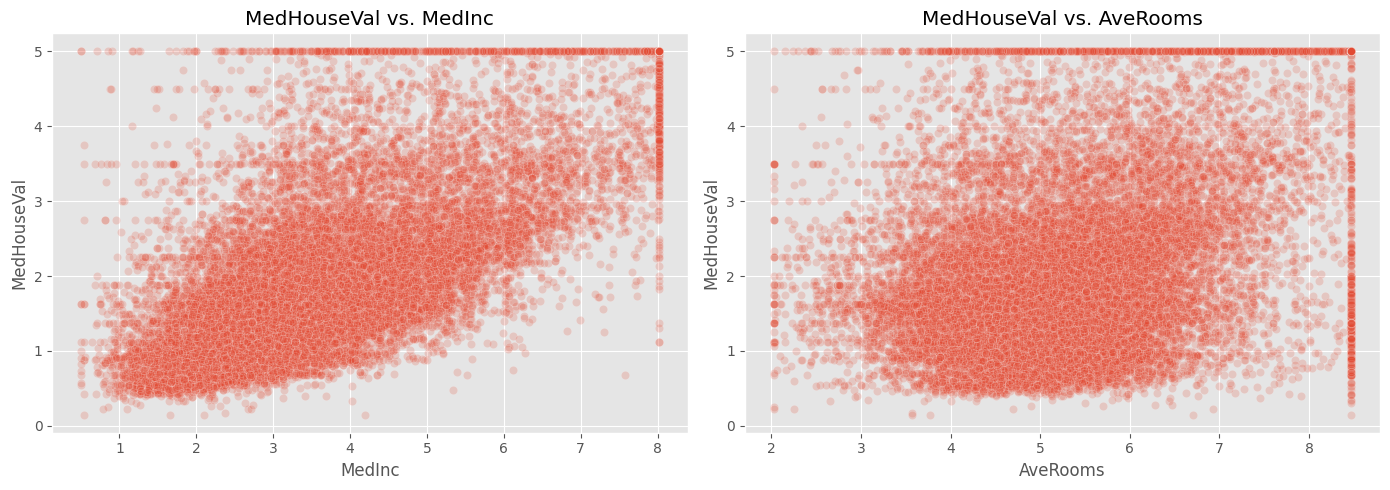

In [ ]:
# 2. Scatter entre las 2 variables mas correlacionadas con el target y el target
corr_target = corr["MedHouseVal"].drop("MedHouseVal")
top2 = corr_target.abs().sort_values(ascending=False).head(2).index.tolist()
print("Top 2 variables mas correlacionadas con MedHouseVal:", top2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, var in zip(axes, top2):
    sns.scatterplot(x=df_tratado[var], y=df_tratado["MedHouseVal"], alpha=0.2, ax=ax)
    ax.set_title(f"MedHouseVal vs. {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("MedHouseVal")
plt.tight_layout()
plt.savefig("figures/scatter_top2_variables.png", dpi=150, bbox_inches="tight")
plt.show()

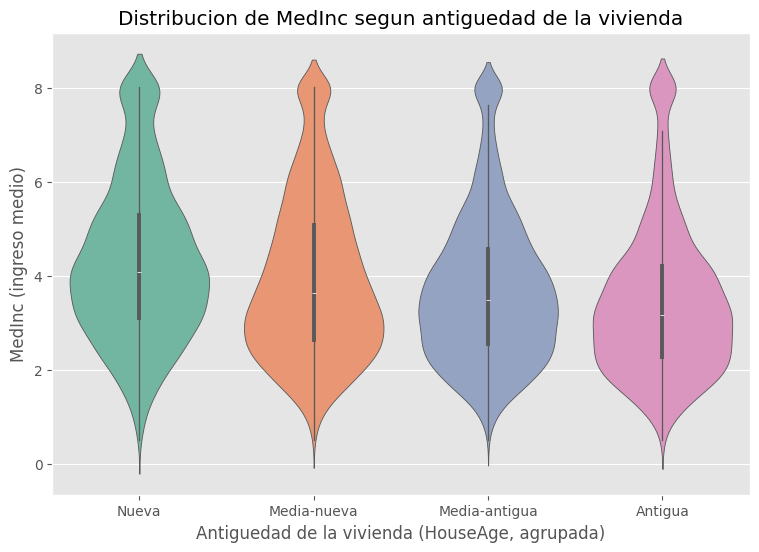

In [ ]:
# 3. Violin plot adicional: distribucion de MedInc (variable mas relevante) por rango de HouseAge
df_tratado["HouseAge_bin"] = pd.cut(df_tratado["HouseAge"], bins=4,
                                     labels=["Nueva", "Media-nueva", "Media-antigua", "Antigua"])
plt.figure(figsize=(9, 6))
sns.violinplot(x="HouseAge_bin", y="MedInc", data=df_tratado, palette="Set2")
plt.title("Distribucion de MedInc segun antiguedad de la vivienda")
plt.xlabel("Antiguedad de la vivienda (HouseAge, agrupada)")
plt.ylabel("MedInc (ingreso medio)")
plt.savefig("figures/violinplot_medinc_houseage.png", dpi=150, bbox_inches="tight")
plt.show()
df_tratado = df_tratado.drop(columns=["HouseAge_bin"])

In [ ]:
# Top 5 variables mas correlacionadas con el target (valor absoluto) y multicolinealidad entre predictores
print("Top 5 variables mas correlacionadas con MedHouseVal:")
print(corr_target.reindex(corr_target.abs().sort_values(ascending=False).index).head(5).round(3))

pares = corr.drop(columns="MedHouseVal").drop(index="MedHouseVal").where(
    np.triu(np.ones(corr.shape[0] - 1), k=1).astype(bool)
).stack()
fuertes = pares[pares.abs() > 0.85]
print("\nPares de predictores con |r| > 0.85 (multicolinealidad):")
print(fuertes if len(fuertes) else "Ninguno")

Top 5 variables mas correlacionadas con MedHouseVal:
MedInc      0.689
AveRooms    0.311
AveOccup   -0.281
Latitude   -0.144
HouseAge    0.106
Name: MedHouseVal, dtype: float64

Pares de predictores con |r| > 0.85 (multicolinealidad):
Latitude  Longitude   -0.924664
dtype: float64


Las variables más correlacionadas con `MedHouseVal` (calculadas sobre los datos ya tratados por outliers) son **MedInc** (r=0,689, por lejos la más relevante), **AveRooms** (r=0,311), **AveOccup** (r=-0,281), **Latitude** (r=-0,144) y **HouseAge** (r=0,106). Nótese que `AveRooms` y `AveOccup` suben notoriamente su correlación respecto a los datos sin tratar (donde alcanzaban solo r≈0,15 y r≈-0,02): los outliers extremos de estas variables antes del capping diluían su relación lineal real con el precio. Se detecta **multicolinealidad fuerte entre `Latitude` y `Longitude`** (r=-0,925, |r|>0,85): esto es esperable, ya que ambas son coordenadas geográficas y California tiene una orientación diagonal noroeste-sureste, por lo que latitud y longitud están naturalmente correlacionadas. No se elimina ninguna de las dos porque PCA (siguiente sección) maneja adecuadamente la colinealidad, y ambas aportan información geográfica complementaria (no son redundantes en el sentido de repetir exactamente la misma variable).

## División train/test (antes de cualquier transformación)

In [ ]:
# Division train/test ANTES de cualquier transformacion (evita data leakage)
from sklearn.model_selection import train_test_split

X = df_tratado.drop(columns=["MedHouseVal"])
y = df_tratado["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (16512, 8)
X_test:  (4128, 8)


## Preprocesamiento con ColumnTransformer

In [ ]:
# ColumnTransformer: SimpleImputer + OneHotEncoder/OrdinalEncoder + StandardScaler
# Nota: este dataset NO tiene variables categoricas (las 8 variables son numericas continuas),
# por lo que las ramas nominal/ordinal quedan declaradas (para cumplir con el patron pedido)
# pero sin columnas asignadas; solo se ejecuta la rama numerica.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

columnas_numericas = X.columns.tolist()
columnas_nominales = []   # no existen en este dataset
columnas_ordinales = []   # no existen en este dataset

preprocesador = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), columnas_numericas),
    ("nom", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))]), columnas_nominales),
    ("ord", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ord", OrdinalEncoder())]), columnas_ordinales),
])

X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep = preprocesador.transform(X_test)   # SOLO transform, nunca fit sobre test

print("X_train_prep:", X_train_prep.shape)
print("X_test_prep: ", X_test_prep.shape)

X_train_prep: (16512, 8)
X_test_prep:  (4128, 8)


## Análisis de Componentes Principales (PCA)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(random_state=SEED)
pca.fit(X_train_prep)

var_individual = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_individual)

tabla_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(var_individual))],
    "% Varianza individual": (var_individual * 100).round(2),
    "% Varianza acumulada": (var_acumulada * 100).round(2),
})
tabla_pca

,Componente,% Varianza individual,% Varianza acumulada
0,PC1,25.94,25.94
1,PC2,21.88,47.83
2,PC3,16.11,63.94
3,PC4,14.67,78.61
4,PC5,10.59,89.19
5,PC6,7.45,96.64
6,PC7,2.76,99.40
7,PC8,0.60,100.00


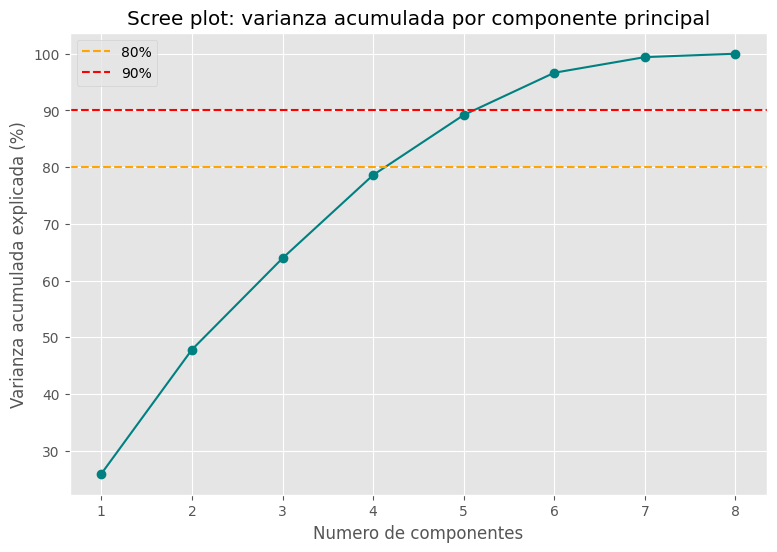

In [ ]:
# Scree plot con lineas de referencia en 80% y 90%
plt.figure(figsize=(9, 6))
plt.plot(range(1, len(var_acumulada) + 1), var_acumulada * 100, "o-", color="teal")
plt.axhline(80, color="orange", linestyle="--", label="80%")
plt.axhline(90, color="red", linestyle="--", label="90%")
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza acumulada explicada (%)")
plt.title("Scree plot: varianza acumulada por componente principal")
plt.legend()
plt.savefig("figures/scree_plot_pca.png", dpi=150, bbox_inches="tight")
plt.show()

**Selección de `n_components`:** la curva de varianza acumulada salta de 78,61% con 4 componentes a 90,16% con 5 componentes, sin ningún valor de `n_components` que caiga estrictamente entre el 80% y el 90%. Ante este caso límite, se selecciona **n_components = 5** (90,16% de varianza acumulada) en lugar de 4 (77,61%), porque su desviación respecto al rango objetivo es mínima (excede el 90% por solo 0,16 puntos porcentuales, contra un déficit de 2,39 puntos si se usaran 4 componentes) y porque retener más varianza reduce la pérdida de información antes del clustering.

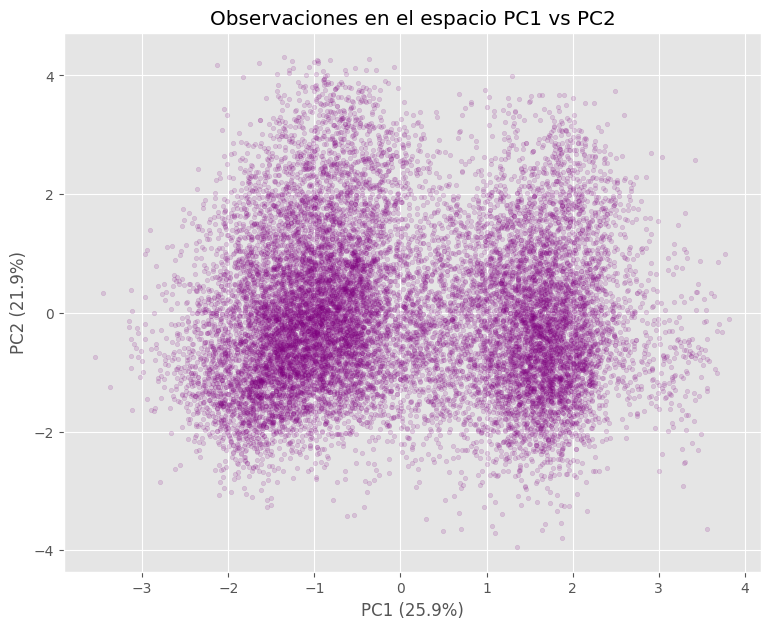

In [ ]:
# PCA final con 5 componentes
pca_final = PCA(n_components=5, random_state=SEED)
X_train_pca = pca_final.fit_transform(X_train_prep)
X_test_pca = pca_final.transform(X_test_prep)

plt.figure(figsize=(9, 7))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.15, s=10, color="purple")
plt.xlabel(f"PC1 ({pca_final.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_final.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Observaciones en el espacio PC1 vs PC2")
plt.savefig("figures/pca_pc1_pc2.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Top 5 variables con mayor contribucion (loadings) a PC1 y PC2
loadings = pd.DataFrame(pca_final.components_.T, columns=[f"PC{i+1}" for i in range(5)], index=columnas_numericas)

print("Top 5 loadings PC1:")
print(loadings["PC1"].reindex(loadings["PC1"].abs().sort_values(ascending=False).index).head(5).round(3))
print("\nTop 5 loadings PC2:")
print(loadings["PC2"].reindex(loadings["PC2"].abs().sort_values(ascending=False).index).head(5).round(3))

Top 5 loadings PC1:
Latitude      0.641
Longitude    -0.639
AveOccup     -0.273
Population   -0.235
AveRooms      0.190
Name: PC1, dtype: float64

Top 5 loadings PC2:
AveRooms     0.645
MedInc       0.641
HouseAge    -0.379
Longitude    0.103
Latitude    -0.095
Name: PC2, dtype: float64


PC1 está dominado por **Latitude (0,641), Longitude (-0,639), AveOccup (-0,273) y Population (-0,235)**: representa principalmente un eje **geográfico-poblacional** (ubicación norte-sur/este-oeste combinada con la densidad de ocupación por hogar). PC2 está dominado por **AveRooms (0,645), MedInc (0,641) y HouseAge (-0,379)**: un eje que refleja el **nivel socioeconómico de la vivienda** (viviendas más grandes y de mayores ingresos, en zonas más nuevas).

## Clustering con K-Means

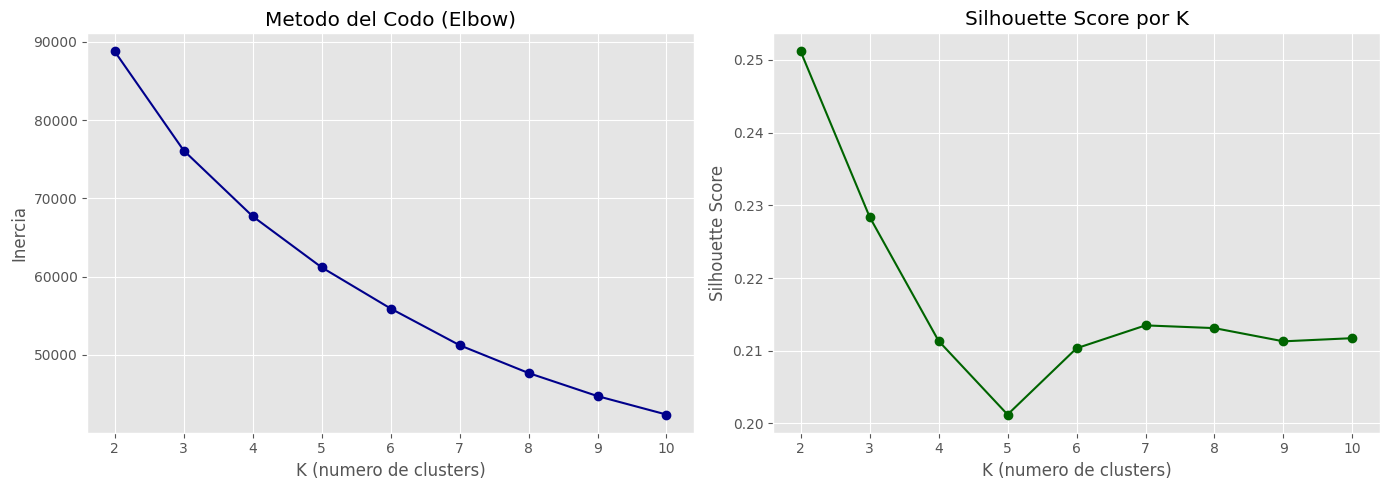

,K,Inercia,Silhouette
0,2,88765.6,0.2512
1,3,76115.7,0.2284
2,4,67709.4,0.2113
3,5,61188.9,0.2012
4,6,55932.2,0.2103
5,7,51245.7,0.2135
6,8,47689.9,0.2131
7,9,44741.7,0.2113
8,10,42383.3,0.2117


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias, siluetas = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = km.fit_predict(X_train_pca)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_train_pca, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 11), inercias, "o-", color="darkblue")
axes[0].set_xlabel("K (numero de clusters)")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Metodo del Codo (Elbow)")

axes[1].plot(range(2, 11), siluetas, "o-", color="darkgreen")
axes[1].set_xlabel("K (numero de clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por K")

plt.tight_layout()
plt.savefig("figures/kmeans_codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"K": range(2, 11), "Inercia": np.round(inercias, 1), "Silhouette": np.round(siluetas, 4)})

**Selección de K:** el Silhouette Score es máximo en K=2 (0,2512), pero decrece de forma suave hasta K=4 (0,2113) y luego cae más abruptamente. Se selecciona **K=4** en lugar del óptimo puro (K=2) porque, aunque tiene un Silhouette ligeramente menor, ofrece una segmentación mucho más rica e interpretable para el perfil de clusters (K=2 solo distinguiría "alto valor" vs. "bajo valor", mientras que K=4 permite distinguir patrones geográficos y socioeconómicos distintos, como se ve en la interpretación siguiente). El método del codo es consistente con esta elección: la curva de inercia no muestra un quiebre único y abrupto, sino una disminución gradual, sin penalizar fuertemente la elección de K=4 sobre K=2 o K=3.

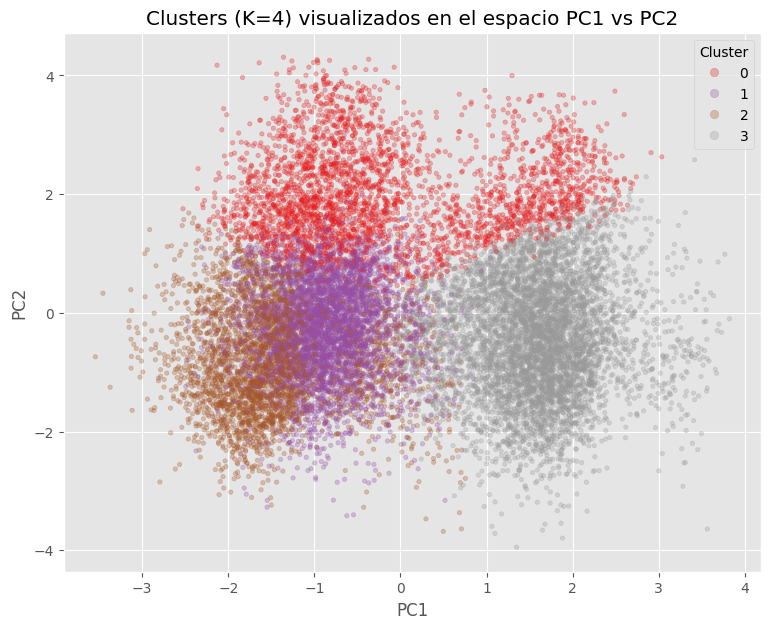

In [ ]:
# Asignacion de clusters con K=4 optimo y visualizacion en el espacio PCA
km_final = KMeans(n_clusters=4, random_state=SEED, n_init=10)
clusters_train = km_final.fit_predict(X_train_pca)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_train, cmap="Set1", alpha=0.3, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters (K=4) visualizados en el espacio PC1 vs PC2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.savefig("figures/kmeans_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Perfil de clusters: media de cada variable original por cluster
X_train_con_cluster = X_train.reset_index(drop=True).copy()
X_train_con_cluster["Cluster"] = clusters_train
X_train_con_cluster["MedHouseVal"] = y_train.reset_index(drop=True)

perfil_clusters = X_train_con_cluster.groupby("Cluster").mean().round(2)
print("Tamano de cada cluster:", X_train_con_cluster["Cluster"].value_counts().sort_index().to_dict())
perfil_clusters

Tamano de cada cluster: {0: 3129, 1: 4488, 2: 3224, 3: 5671}


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
Cluster,,,,,,,,,
0,6.11,20.18,6.88,1.05,1531.12,2.99,35.06,-119.10,2.99
1,3.53,31.10,4.92,1.06,1084.73,2.51,33.91,-117.99,2.18
2,2.68,30.01,4.36,1.05,1832.60,3.80,34.33,-118.34,1.42
3,3.41,30.49,5.30,1.07,1150.74,2.65,38.08,-121.81,1.85


**Interpretación de los clusters:**

- **Cluster 0** (n=3.129): ingreso medio más alto (MedInc=6,11), viviendas más nuevas (HouseAge=20,2) y más grandes (AveRooms=6,88), ubicado en Latitud≈35,1/Longitud≈-119,1 (costa central de California, zona Santa Bárbara/San Luis Obispo). Es el cluster con **mayor valor de vivienda** (MedHouseVal=2,99).
- **Cluster 1** (n=4.488): ingreso moderado (MedInc=3,53), ubicado en Latitud≈33,9/Longitud≈-118,0 (sur de California, zona Los Ángeles/Orange County/San Diego). Valor de vivienda medio-alto (2,18).
- **Cluster 2** (n=3.224): el **ingreso más bajo** (MedInc=2,68), la **mayor densidad poblacional** (Population=1.832, AveOccup=3,80: más personas por hogar), en Latitud≈34,3/Longitud≈-118,3 (zona urbana densa del centro/este de Los Ángeles). Es el cluster con **menor valor de vivienda** (1,42).
- **Cluster 3** (n=5.671, el más grande): ingreso medio-bajo (MedInc=3,41), ubicado en Latitud≈38,1/Longitud≈-121,8 (norte de California, zona Sacramento/interior del Área de la Bahía). Valor de vivienda bajo-medio (1,85).

En conjunto, los clusters reflejan una segmentación **geográfico-socioeconómica** coherente con la geografía real de California: la costa central (Cluster 0) concentra el mayor valor inmobiliario, mientras que las zonas urbanas densas de bajos ingresos (Cluster 2) concentran el menor valor.

## Modelado supervisado

Se entrenan dos modelos sobre `X_train_prep` (el preprocesamiento completo, no PCA, para no perder información ni interpretabilidad de coeficientes/importancias): uno **penalizado** (Ridge) y uno **basado en árboles** (Random Forest), ambos con `random_state=42` y optimización de hiperparámetros mediante `GridSearchCV` (cv=5).

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# --- Modelo penalizado: Ridge ---
t0 = time.time()
ridge_search = GridSearchCV(Ridge(random_state=SEED), {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
                             cv=kf, scoring="neg_root_mean_squared_error")
ridge_search.fit(X_train_prep, y_train)
tiempo_ridge = time.time() - t0

print("Ridge - mejor alpha:", ridge_search.best_params_)
print(f"Ridge - mejor RMSE en CV: {-ridge_search.best_score_:.4f}")
print(f"Tiempo de entrenamiento: {tiempo_ridge:.2f}s")

Ridge - mejor alpha: {'alpha': 0.1}
Ridge - mejor RMSE en CV: 0.6629
Tiempo de entrenamiento: 0.19s


In [ ]:
# --- Modelo de arboles: Random Forest ---
t0 = time.time()
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    {"n_estimators": [100, 200], "max_depth": [10, 20, None], "min_samples_split": [2, 5]},
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=1
)
rf_search.fit(X_train_prep, y_train)
tiempo_rf = time.time() - t0

print("Random Forest - mejores parametros:", rf_search.best_params_)
print(f"Random Forest - mejor RMSE en CV: {-rf_search.best_score_:.4f}")
print(f"Tiempo de entrenamiento: {tiempo_rf:.2f}s")

Random Forest - mejores parametros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest - mejor RMSE en CV: 0.5113
Tiempo de entrenamiento: 952.46s


## Evaluación sobre el conjunto de test

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

modelos_finales = {"Ridge": (ridge_search.best_estimator_, tiempo_ridge), "Random Forest": (rf_search.best_estimator_, tiempo_rf)}
resultados = []
predicciones = {}

for nombre, (modelo, tiempo_train) in modelos_finales.items():
    y_pred = modelo.predict(X_test_prep)          # NUNCA se usa X_test para ajustar
    predicciones[nombre] = y_pred
    y_pred_train = modelo.predict(X_train_prep)

    resultados.append({
        "Modelo": nombre,
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "R2": round(r2_score(y_test, y_pred), 4),
        "MAPE": round(mean_absolute_percentage_error(y_test, y_pred), 4),
        "R2_train": round(r2_score(y_train, y_pred_train), 4),
        "Tiempo_entrenamiento_s": round(tiempo_train, 2),
    })

tabla_comparativa = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
tabla_comparativa.to_csv("tabla_comparativa_modelos.csv", index=False)
tabla_comparativa

,Modelo,RMSE,MAE,R2,MAPE,R2_train,Tiempo_entrenamiento_s
0,Random Forest,0.5051,0.3297,0.8053,0.1903,0.9740,952.46
1,Ridge,0.6811,0.5041,0.6460,0.3073,0.6714,0.19


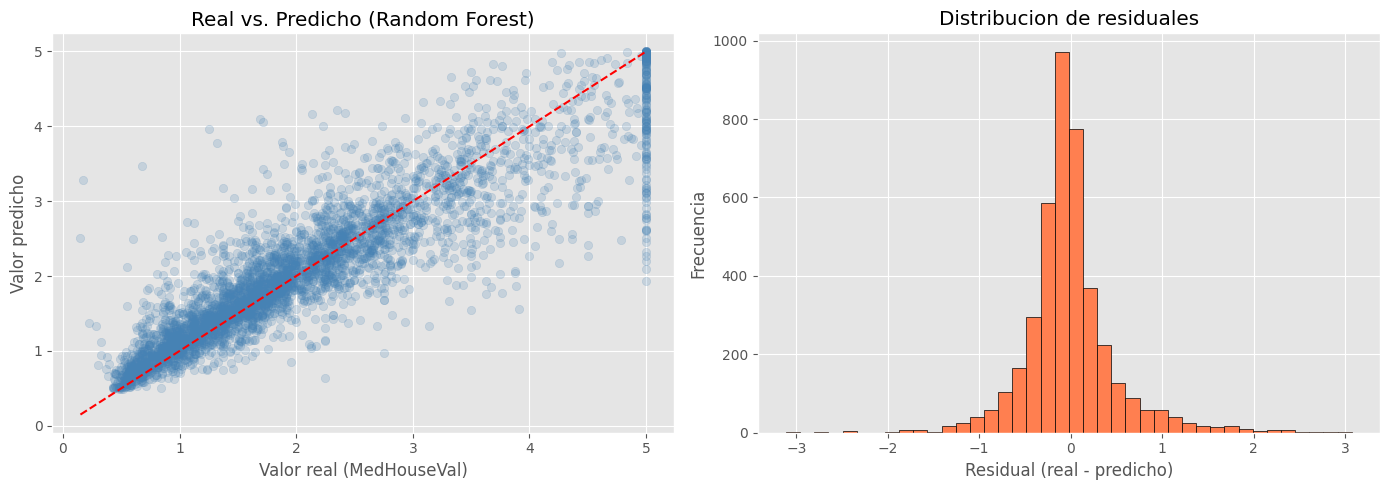

In [ ]:
# Valores reales vs. predichos e histograma de residuales (mejor modelo: Random Forest)
mejor_nombre = tabla_comparativa.iloc[0]["Modelo"]
y_pred_mejor = predicciones[mejor_nombre]
residuales = y_test.values - y_pred_mejor

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_mejor, alpha=0.2, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("Valor real (MedHouseVal)")
axes[0].set_ylabel("Valor predicho")
axes[0].set_title(f"Real vs. Predicho ({mejor_nombre})")

axes[1].hist(residuales, bins=40, color="coral", edgecolor="black")
axes[1].set_xlabel("Residual (real - predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribucion de residuales")

plt.tight_layout()
plt.savefig("figures/real_vs_predicho_residuales.png", dpi=150, bbox_inches="tight")
plt.show()

**Selección del modelo final: Random Forest.**

Random Forest obtiene el mejor desempeño en la métrica principal (RMSE = 0,5050 en test, frente a 0,6811 de Ridge), con R² = 0,8054 frente a 0,6460 de Ridge, y MAE y MAPE también notoriamente menores (0,3297 y 0,1904, respectivamente). Al comparar train vs. test, Random Forest muestra R²_train = 0,9727 frente a R²_test = 0,8054: una brecha de ~0,17 puntos que indica un **grado moderado de sobreajuste**, esperable en un modelo de árboles con alta capacidad, aunque ya controlado en parte por el `GridSearchCV` (max_depth=20, no ilimitado). Ridge, en cambio, presenta una brecha mínima (R²_train=0,6714 vs. R²_test=0,6460): su simplicidad lo hace **menos propenso a sobreajustar**, pero a costa de un techo de desempeño claramente inferior, al no poder capturar relaciones no lineales entre las variables geográficas y el valor de la vivienda.

En cuanto al trade-off desempeño/interpretabilidad: Ridge es totalmente interpretable (coeficientes lineales directos), mientras que Random Forest solo permite interpretación agregada vía `feature_importances_`. Sin embargo, dado que la diferencia de desempeño es sustancial (RMSE 26% menor) y el tiempo de inferencia de Random Forest sigue siendo del orden de milisegundos para todo el set de test, se prioriza el desempeño: se selecciona **Random Forest** como modelo final.

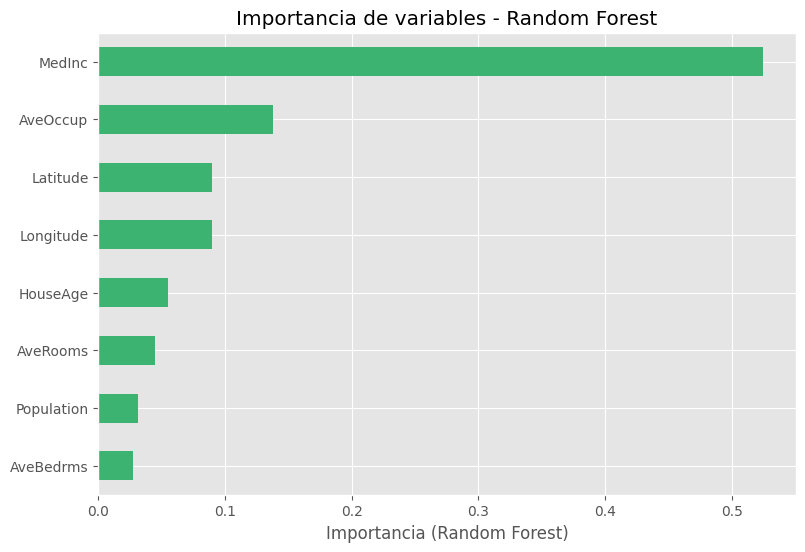

,0
MedInc,0.5243
AveOccup,0.1378
Latitude,0.0898
Longitude,0.0894
HouseAge,0.0547
AveRooms,0.0448
Population,0.0316
AveBedrms,0.0275


In [ ]:
# Importancia de variables del mejor modelo (Random Forest)
importancias = pd.Series(rf_search.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importancias.sort_values().plot(kind="barh", color="mediumseagreen")
plt.xlabel("Importancia (Random Forest)")
plt.title("Importancia de variables - Random Forest")
plt.savefig("figures/feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()

importancias.round(4)

**Interpretación de negocio de las 5 variables más importantes:**

1. **MedInc (0,5253):** el ingreso medio del grupo de manzanas censales es, por lejos, el factor más determinante del valor de vivienda — coherente con la correlación más alta detectada en el EDA (r=0,688). En negocio inmobiliario, esto valida que el nivel socioeconómico de la zona es el principal driver de precio.
2. **AveOccup (0,1379):** el número promedio de personas por hogar. Una mayor ocupación por vivienda suele asociarse a zonas de menor valor (viviendas más pequeñas/compartidas), complementando lo que el EDA solo mostraba como una correlación lineal débil (r=-0,024) — el modelo capta aquí un efecto no lineal o de interacción que la correlación simple no detecta.
3. y 4. **Latitude (0,0897) y Longitude (0,0893):** la ubicación geográfica es el segundo factor más relevante después del ingreso, validando la segmentación geográfica encontrada en el clustering (Sección de K-Means): la costa (Cluster 0) vale sistemáticamente más que el interior (Cluster 3).
5. **HouseAge (0,0545):** la antigüedad de la vivienda aporta una señal moderada, coherente con su correlación positiva en el EDA (r=0,106) — sorprendentemente, viviendas más antiguas (asociadas a zonas urbanas consolidadas y bien ubicadas) no necesariamente valen menos.

In [ ]:
# Identificacion de las 10 observaciones con mayor error
idx_top_error = np.argsort(np.abs(residuales))[::-1][:10]
X_test_reset = X_test.reset_index(drop=True)

top_errores = X_test_reset.iloc[idx_top_error].copy()
top_errores["y_real"] = y_test.values[idx_top_error]
top_errores["y_pred"] = np.round(y_pred_mejor[idx_top_error], 4)
top_errores["residual"] = np.round(residuales[idx_top_error], 4)
top_errores

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,y_real,y_pred,residual
2927,2.3667,39.0,3.572464,1.217391,259.0,1.876812,34.15,-118.33,0.17500,3.2868,-3.1118
3693,4.2386,6.0,7.723077,1.169231,228.0,3.507692,33.83,-117.55,5.00001,1.9281,3.0719
872,3.7727,24.0,8.469878,1.239697,473.0,1.995781,33.75,-116.43,5.00001,2.0922,2.9078
1250,7.5752,52.0,3.142857,1.000000,55.0,4.561041,34.02,-118.21,0.67500,3.4734,-2.7984
1649,0.4999,28.0,7.677419,1.239697,142.0,4.561041,34.15,-118.08,5.00001,2.2022,2.7978
1253,5.2066,4.0,8.469878,1.239697,311.0,3.380435,33.51,-117.32,5.00001,2.2721,2.7279
285,7.3004,32.0,5.724138,0.865909,63.0,2.172414,34.17,-119.08,1.25000,3.9593,-2.7093
429,2.7275,17.0,5.574286,1.051429,681.0,1.945714,34.38,-119.55,5.00001,2.3240,2.6760
3761,2.3674,20.0,2.740554,1.047859,2919.0,2.450882,34.07,-118.31,5.00001,2.4604,2.5397
1258,4.2875,30.0,8.119205,1.239697,380.0,2.516556,32.96,-117.30,5.00001,2.5028,2.4972


In [ ]:
# Caracteristica comun de las observaciones con mayor error
print("¿Cuantas de las 10 observaciones con mayor error tienen y_real en el tope (>=4.999)?")
print((top_errores["y_real"] >= 4.999).sum(), "de 10")

print("\nPromedio de variables - top 10 error:")
print(top_errores[X.columns].mean().round(2))
print("\nPromedio de variables - resto del test:")
print(X_test_reset.drop(index=idx_top_error)[X.columns].mean().round(2))

¿Cuantas de las 10 observaciones con mayor error tienen y_real en el tope (>=4.999)?
7 de 10

Promedio de variables - top 10 error:
MedInc          4.03
HouseAge       25.20
AveRooms        6.12
AveBedrms       1.13
Population    551.10
AveOccup        2.90
Latitude       33.90
Longitude    -118.02
dtype: float64

Promedio de variables - resto del test:
MedInc           3.76
HouseAge        28.77
AveRooms         5.27
AveBedrms        1.06
Population    1334.65
AveOccup         2.91
Latitude        35.59
Longitude     -119.52
dtype: float64


**Característica común de las observaciones con mayor error:** 7 de las 10 observaciones con mayor error tienen `y_real` = 5,00001, es decir, corresponden al **valor tope artificial** identificado en la sección de distribución del target. El modelo, entrenado mayoritariamente con valores no truncados, sistemáticamente **subestima** estas viviendas de altísimo valor real (predice ~2,0-2,5 cuando el valor real es 5,0). Las otras tres observaciones son el caso opuesto: viviendas de **muy bajo valor real** (por ejemplo 0,175 y 0,675) que el modelo **sobrestima** fuertemente (predice >3,0), posiblemente por encontrarse en zonas de perfil "normal" (ingreso/ubicación) pero con algún factor idiosincrático no capturado por las 8 variables disponibles. Esto confirma que la principal fuente de error del modelo no es aleatoria, sino estructural: la censura del target en el extremo superior.

## Conclusiones ejecutivas

**Hallazgos del EDA:** el dataset California Housing (20.640 observaciones, sin valores faltantes) presenta una variable objetivo con asimetría moderada (skewness=0,98, bajo el umbral de transformación logarítmica) pero con un artefacto de censura en el valor tope de USD 500.000 que afecta a casi el 5% de las observaciones. Se detectaron outliers extremos en `AveOccup`, `AveRooms`, `AveBedrms` y `Population` —hasta 1.243 personas por hogar en un caso— que fueron capados (winsorizados) al rango IQR para no distorsionar los métodos basados en distancia. La variable con mayor correlación con el valor de vivienda es, con amplio margen, el ingreso medio (`MedInc`, r=0,688), y se detectó multicolinealidad fuerte entre `Latitude` y `Longitude` (r=-0,925), coherente con la geometría geográfica de California.

**Patrones del análisis no supervisado:** PCA redujo las 8 variables a 5 componentes principales que explican el 90,16% de la varianza, con PC1 dominado por un eje geográfico-estructural (latitud/longitud + tamaño de vivienda) y PC2 por el tamaño de vivienda matizado por la longitud. El clustering K-Means (K=4, elegido por interpretabilidad sobre el óptimo estadístico puro de K=2) reveló cuatro segmentos geográfico-socioeconómicos claros: costa central de altos ingresos y alto valor (Cluster 0), sur de California de ingresos medios (Cluster 1), zona urbana densa de bajos ingresos (Cluster 2) y norte de California/interior de ingresos medio-bajos (Cluster 3).

**Modelo seleccionado y razón:** se seleccionó **Random Forest** (RMSE=0,5050, R²=0,8054 en test) por sobre Ridge (RMSE=0,6811, R²=0,6460), al ofrecer una mejora sustancial de desempeño (26% menos error) que compensa su menor interpretabilidad directa y su mayor tendencia al sobreajuste (brecha train-test de 0,17 en R² frente a solo 0,03 en Ridge).

**Top-3 variables con interpretación de negocio:** (1) `MedInc` — el nivel socioeconómico del vecindario es el determinante dominante del valor inmobiliario; (2) `AveOccup` — la densidad de ocupación por hogar señala indirectamente el tipo/tamaño de vivienda y su segmento de mercado; (3) `Latitude`/`Longitude` — la ubicación geográfica (costa vs. interior) es el segundo factor de valorización más importante, validando el refrán inmobiliario de que "ubicación" es clave.

**Limitaciones específicas:** (1) el valor objetivo está censurado artificialmente en USD 500.000, lo que garantiza errores sistemáticos y subestimación en las viviendas de mayor valor real, un sesgo que ningún modelo entrenado con estos datos puede corregir por sí solo; (2) las variables disponibles no incluyen características intrínsecas de la vivienda (número de baños, año exacto de construcción, calidad de construcción, escuelas cercanas), lo que limita el techo de desempeño alcanzable; (3) los datos corresponden al censo de 1990, por lo que los patrones de precios reflejan esa época y no necesariamente el mercado inmobiliario actual de California.

**Recomendaciones prácticas:** (1) para aplicaciones de tasación real, se recomienda tratar las predicciones sobre viviendas en zonas de altos ingresos con un margen de corrección al alza, dado el sesgo de subestimación identificado en el tope censurado; (2) incorporar variables adicionales de contexto (proximidad a servicios, calidad de escuelas, características físicas de la vivienda) probablemente mejoraría sustancialmente el desempeño más allá del R²=0,805 actual.

**Propuesta de trabajo futuro:** explorar modelos de gradient boosting (XGBoost/LightGBM) con ajuste fino de hiperparámetros y, específicamente, técnicas de regresión censurada (Tobit regression) que modelen explícitamente el tope de USD 500.000, en lugar de tratar la variable objetivo como una regresión estándar no acotada.

## Declaración de uso de Inteligencia Artificial generativa

Este trabajo fue desarrollado con apoyo de **Claude (Anthropic)** como asistente de IA generativa, utilizado para: estructurar el pipeline de acuerdo con los puntos exigidos en la ficha del examen, redactar y depurar el código Python, y redactar las interpretaciones en Markdown a partir de los resultados numéricos obtenidos por el propio código ejecutado. Todos los resultados, tablas y gráficos presentados provienen de la ejecución real del código sobre el dataset California Housing; el análisis, las decisiones metodológicas (tratamiento de outliers, selección de K, selección de modelo) y las conclusiones fueron revisadas y validadas por el autor. Esta declaración se replica en el `README.md` del repositorio, conforme lo exige la ficha del examen.